# Link to Kaggle  
https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction?select=medical_insurance.csv

# EDA, Outlier Checks & Preprocessing
In this section we will:
- See how the dataset is organised
- Remove the missing values
- Check for the possible outliers
- Visualise the most important data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, KFold
from google.colab import drive
drive.mount('/content/drive')

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

Mounted at /content/drive


In [ ]:
df = pd.read_csv("medical_insurance.csv")
print("\n\n1. Exploration of the Data Organisation")
print("-" * 272)
print("Dataset Shape :")
display(df.shape)
print("Dataset First 5 Rows :")
display(df.head())



1. Exploration of the Data Organisation
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dataset Shape :


(100000, 54)

Dataset First 5 Rows :


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


In [ ]:
print("Data Types present in the dataset :")
display(df.dtypes)

Data Types present in the dataset :


,0
person_id,int64
age,int64
sex,object
region,object
urban_rural,object
income,float64
education,object
marital_status,object
employment_status,object
household_size,int64


In [ ]:
print("Number of missing values per column:")
display(df.isna().sum())

Number of missing values per column:


,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


In [ ]:
print("Summary of the dataset columns (float and integer columns) :")
display(df.describe(include=[np.number]))

Summary of the dataset columns (float and integer columns) :


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,73.604770,119.975065,5.605968,1226.725000,19.520400,5.517760,0.050690,3.598920,0.519849,3009.451907,582.320040,48.526668,1.62178,656.512084,1377.878827,0.724720,0.203450,0.085930,0.058870,0.035950,0.051170,0.021510,0.014620,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,8.900924,30.262086,0.845996,1019.619375,10.286255,2.868827,0.224591,0.594052,0.250669,3127.462822,399.583722,33.298640,2.02982,1072.660048,2305.464687,0.805523,0.402566,0.280262,0.235382,0.186166,0.220345,0.145078,0.120027,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,40.000000,30.000000,3.540000,500.000000,10.000000,1.000000,0.000000,1.500000,0.000000,55.550000,211.670000,17.640000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,67.000000,99.400000,5.160000,500.000000,10.000000,3.000000,0.000000,3.200000,0.329700,1175.117500,352.070000,29.340000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,73.000000,120.000000,5.440000,1000.000000,20.000000,6.000000,0.000000,3.600000,0.505500,2082.575000,463.585000,38.630000,1.00000,318.015000,642.545000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,79.000000,140.300000,5.760000,2000.000000,30.000000,8.000000,0.000000,4.010000,0.703300,3707.957500,666.697500,55.560000,2.00000,872.215000,1795.522500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,114.000000,248.300000,11.940000,5000.000000,50.000000,10.000000,2.000000,5.000000,1.000000,65724.9000

In [ ]:
print("Summary of the dataset columns (object columns) :")
display(df.describe(include=["object"]))

Summary of the dataset columns (object columns) :


,sex,region,urban_rural,education,marital_status,employment_status,smoker,alcohol_freq,plan_type,network_tier
count,100000,100000,100000,100000,100000,100000,100000,69917,100000,100000
unique,3,5,3,6,4,4,3,3,4,4
top,Female,South,Urban,Bachelors,Married,Employed,Never,Occasional,PPO,Silver
freq,49193,28029,60019,27996,53252,55269,69709,45078,35167,40177


In [ ]:
print("\n\n2. Removal of the missing values and potential outliers")
print("-" * 272)
n_dups = df.duplicated().sum()
print(f"Found {n_dups} duplicate rows")

n_na = df.isna().sum().array.sum()
print(f"Found {n_na} rows with missing values")
cols_with_na = df.columns[df.isna().sum().to_numpy() > 0]
display(df[cols_with_na].columns[0])
df = df.drop('alcohol_freq', axis=1)



2. Removal of the missing values and potential outliers
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Found 0 duplicate rows
Found 30083 rows with missing values


'alcohol_freq'

We know that the only columns that has missing values is the 'alcohol_freq' column with 30 thousands rows with missing values, but we have 54 columns and 100 thousands rows, so it's better to drop a columns than droping 30 thousands rows. Moreover we can only use a restrained number of features to train our model. So we will drop the 'alcohol_freq' column.

We will now try to find any outliers value using the mean and standars deviation of each value, we will only select a number of columns that could have possible outliers and those that could really impact the model.

In [ ]:
row_to_drop = []
column_to_watch = ["income","bmi","systolic_bp","diastolic_bp","ldl","hba1c","annual_medical_cost","annual_premium","monthly_premium"
                   ,"claims_count","avg_claim_amount","total_claims_paid"]
for col in column_to_watch:
    nb_outlier = 0
    mean_val = np.mean(df[col])
    sd_val = np.std(df[col])
    for i in range (len(df[col])):
        if (df[col][i] > mean_val + 4*sd_val) or (df[col][i] < mean_val - 4*sd_val):
            row_to_drop.append(i)
            nb_outlier += 1
    print(col,nb_outlier)
row_to_drop = list(dict.fromkeys(row_to_drop))
df = df.drop(row_to_drop)
print("New shape of the dataset after the outliers removal : ")
df.shape

income 931
bmi 4
systolic_bp 5
diastolic_bp 3
ldl 2
hba1c 1363
annual_medical_cost 948
annual_premium 948
monthly_premium 948
claims_count 864
avg_claim_amount 997
total_claims_paid 992
New shape of the dataset after the outliers removal : 


(94995, 53)

In [ ]:
print("Summary of the clean dataset columns (float and integer columns) :")
display(df.describe(include=[np.number]))
print("Summary of the clean dataset columns (object columns) :")
display(df.describe(include=["object"]))

Summary of the clean dataset columns (float and integer columns) :


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000,94995.000000
mean,49972.917711,47.342186,47367.609874,2.430549,0.898037,26.979677,1.843097,0.088057,0.345050,1.211369,117.578715,73.500247,119.903953,5.544111,1226.675088,19.522817,5.516964,0.050666,3.599043,0.510130,2706.230153,544.087941,45.340658,1.504321,574.398776,1162.940473,0.683183,0.196705,0.070098,0.056719,0.034181,0.048918,0.020538,0.013748,0.013927,0.103784,0.124564,0.502311,0.152534,0.502784,0.504342,0.502142,0.352197,0.164209
std,28869.055789,15.959973,38061.390215,1.074751,0.950467,4.991677,1.607259,0.294671,1.305108,1.192315,15.268847,8.857159,30.238760,0.695242,1018.656139,10.284635,2.869023,0.224580,0.594398,0.247165,2238.965466,283.383495,23.615285,1.777295,786.720834,1615.960298,0.773595,0.397510,0.255314,0.231306,0.181694,0.215699,0.141832,0.116444,0.117189,0.304982,0.330226,0.739442,0.447107,0.737259,0.744738,0.739414,0.477658,0.370467
min,1.000000,0.000000,1100.000000,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,61.000000,40.000000,30.000000,3.540000,500.000000,10.000000,1.000000,0.000000,1.500000,0.000000,55.550000,211.670000,17.640000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24979.500000,37.000000,21000.000000,2.000000,0.000000,23.600000,1.000000,0.000000,0.000000,0.000000,107.000000,67.000000,99.400000,5.150000,500.000000,10.000000,3.000000,0.000000,3.200000,0.318700,1151.580000,349.185000,29.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,49977.000000,47.000000,35900.000000,2.000000,1.000000,27.000000,2.000000,0.000000,0.000000,1.000000,117.000000,73.000000,120.000000,5.440000,1000.000000,20.000000,6.000000,0.000000,3.600000,0.494500,2021.580000,456.140000,38.010000,1.000000,303.090000,596.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,74978.500000,58.000000,61100.000000,3.000000,1.000000,30.400000,3.000000,0.000000,0.000000,2.000000,127.000000,79.000000,140.300000,5.740000,2000.000000,20.000000,8.000000,0.000000,4.010000,0.681300,3529.280000,644.785000,53.730000,2.000000,832.005000,1669.625000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,236700.000000,9.000000,7.000000,46.700000,22.000000,3.000000,21.000000,10.000000,179.000000,109.000000,239.500000,8.980000,5000.000000,50.000000,10.000000,2.000000,5.000000,1.000000,15503.500000,2180.310000,181.6900

Summary of the clean dataset columns (object columns) :


,sex,region,urban_rural,education,marital_status,employment_status,smoker,plan_type,network_tier
count,94995,94995,94995,94995,94995,94995,94995,94995,94995
unique,3,5,3,6,4,4,3,4,4
top,Female,South,Urban,Bachelors,Married,Employed,Never,PPO,Silver
freq,46742,26606,57003,26658,50586,52521,66601,33408,38209



3. Exploratory data analysis
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


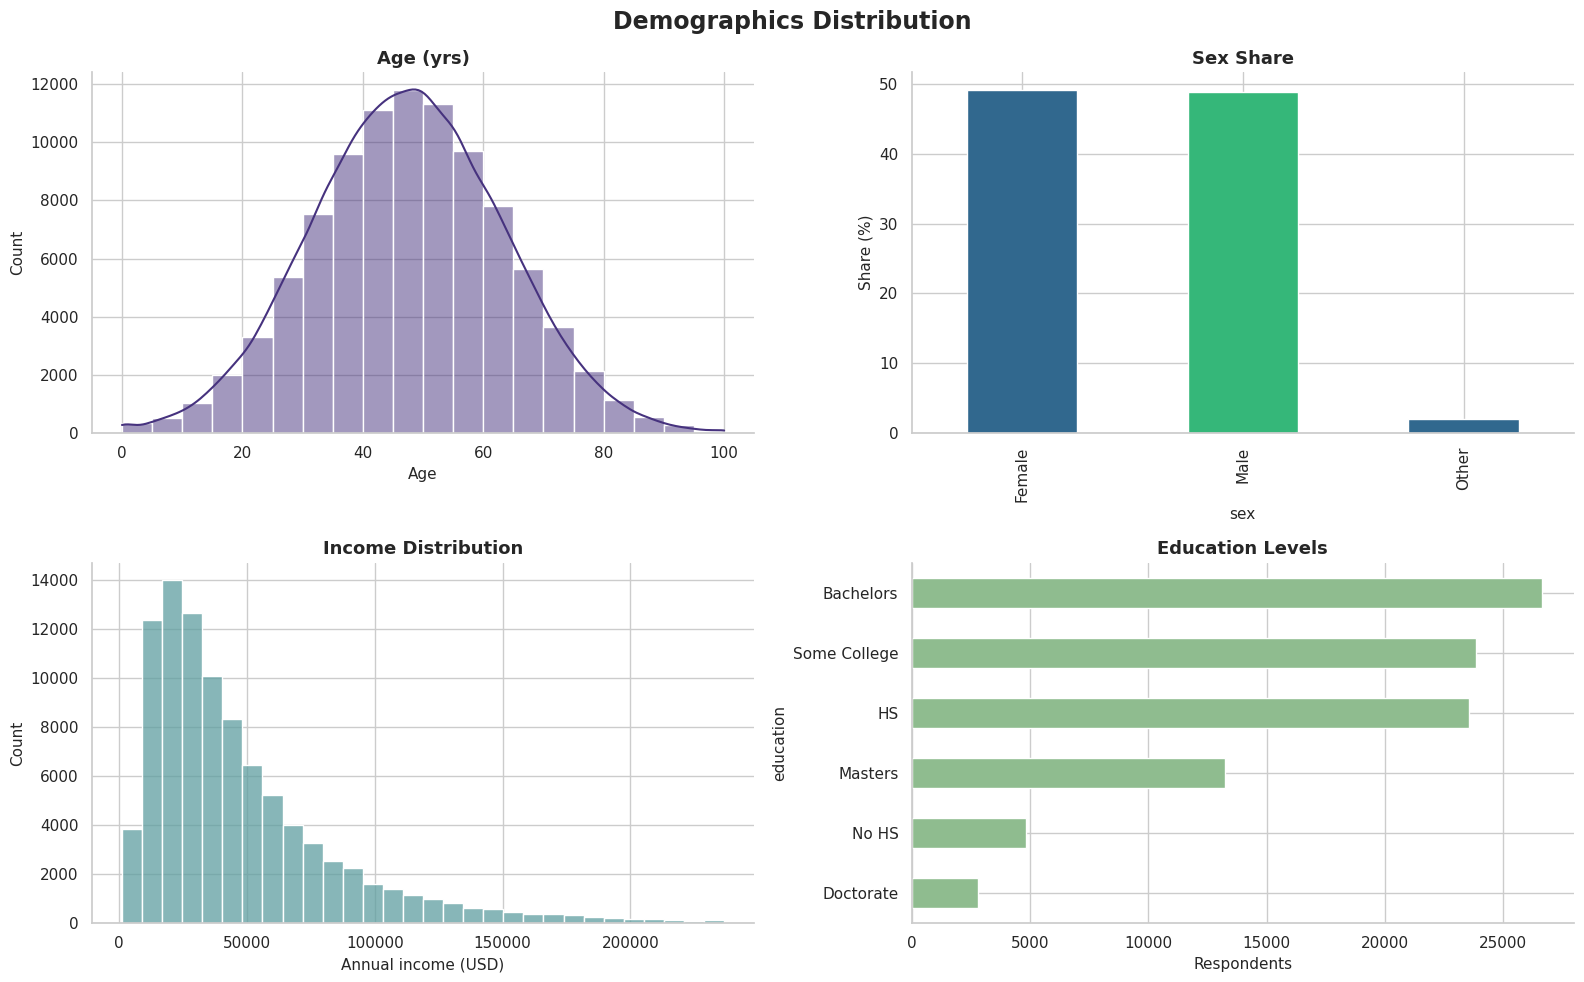

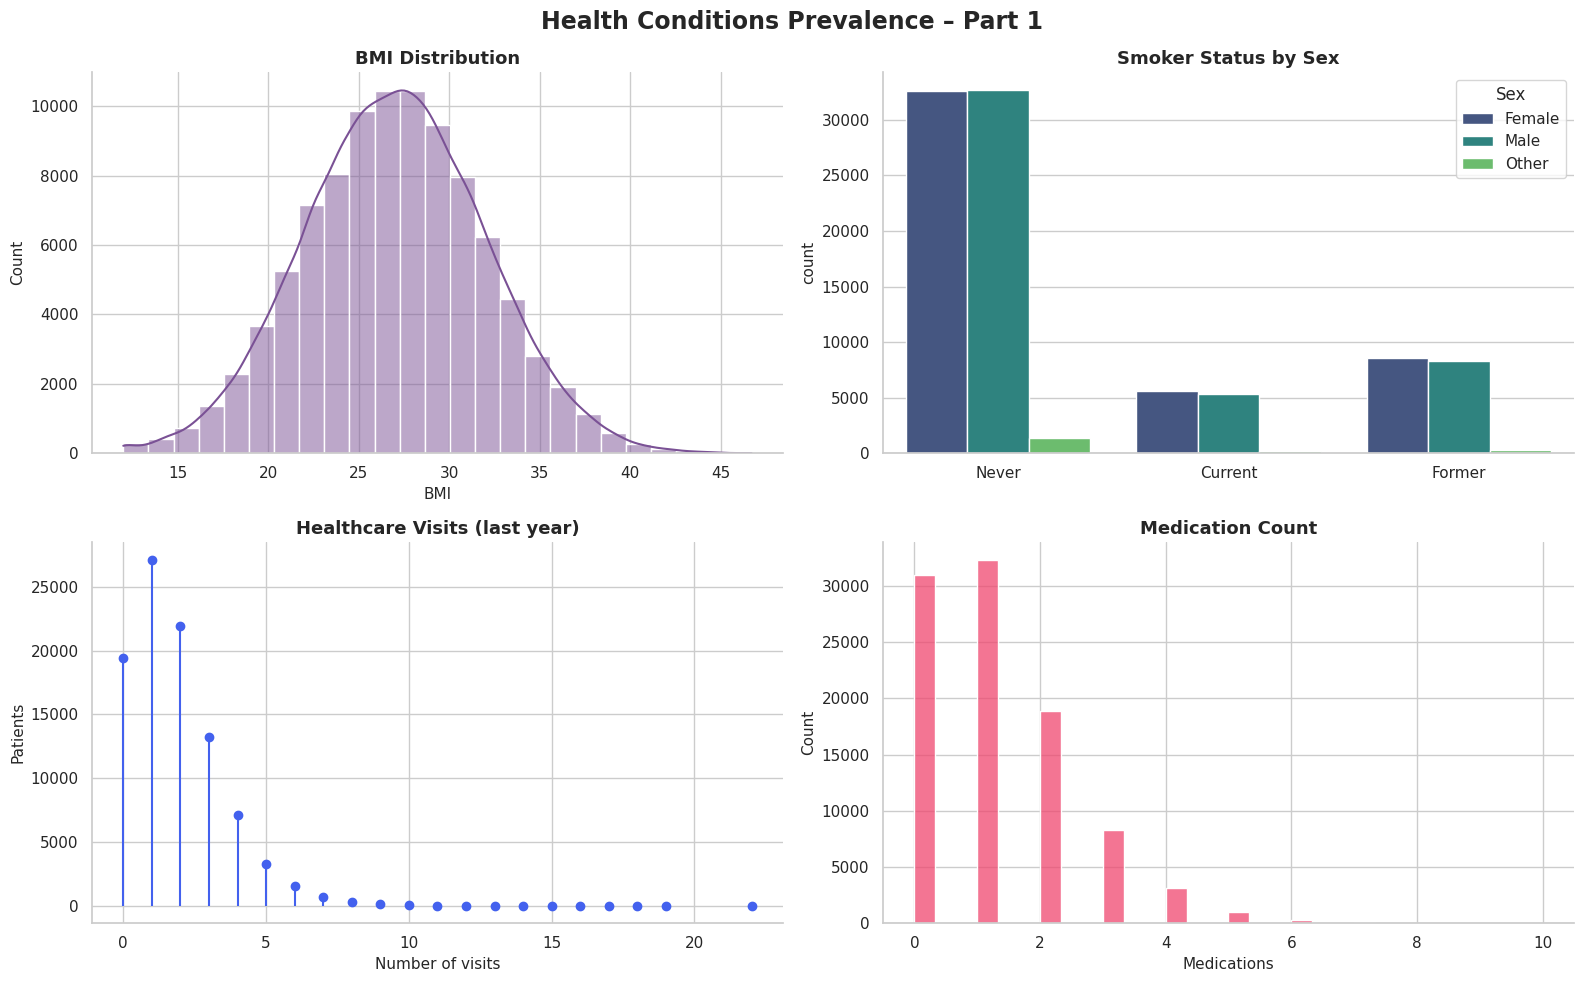

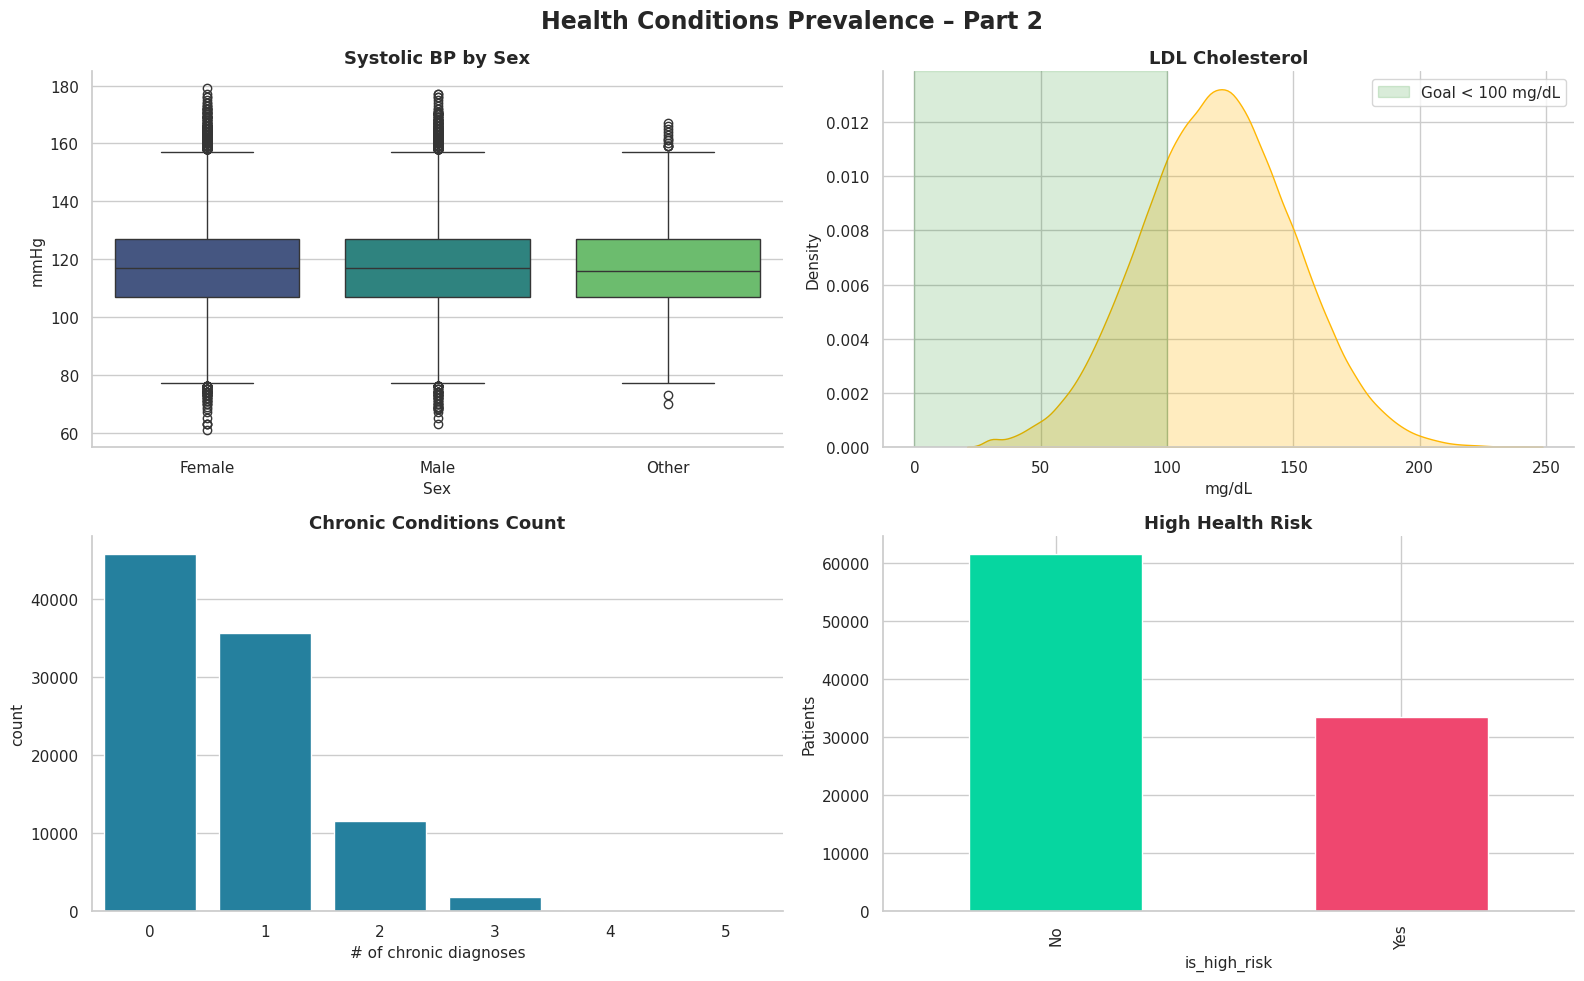

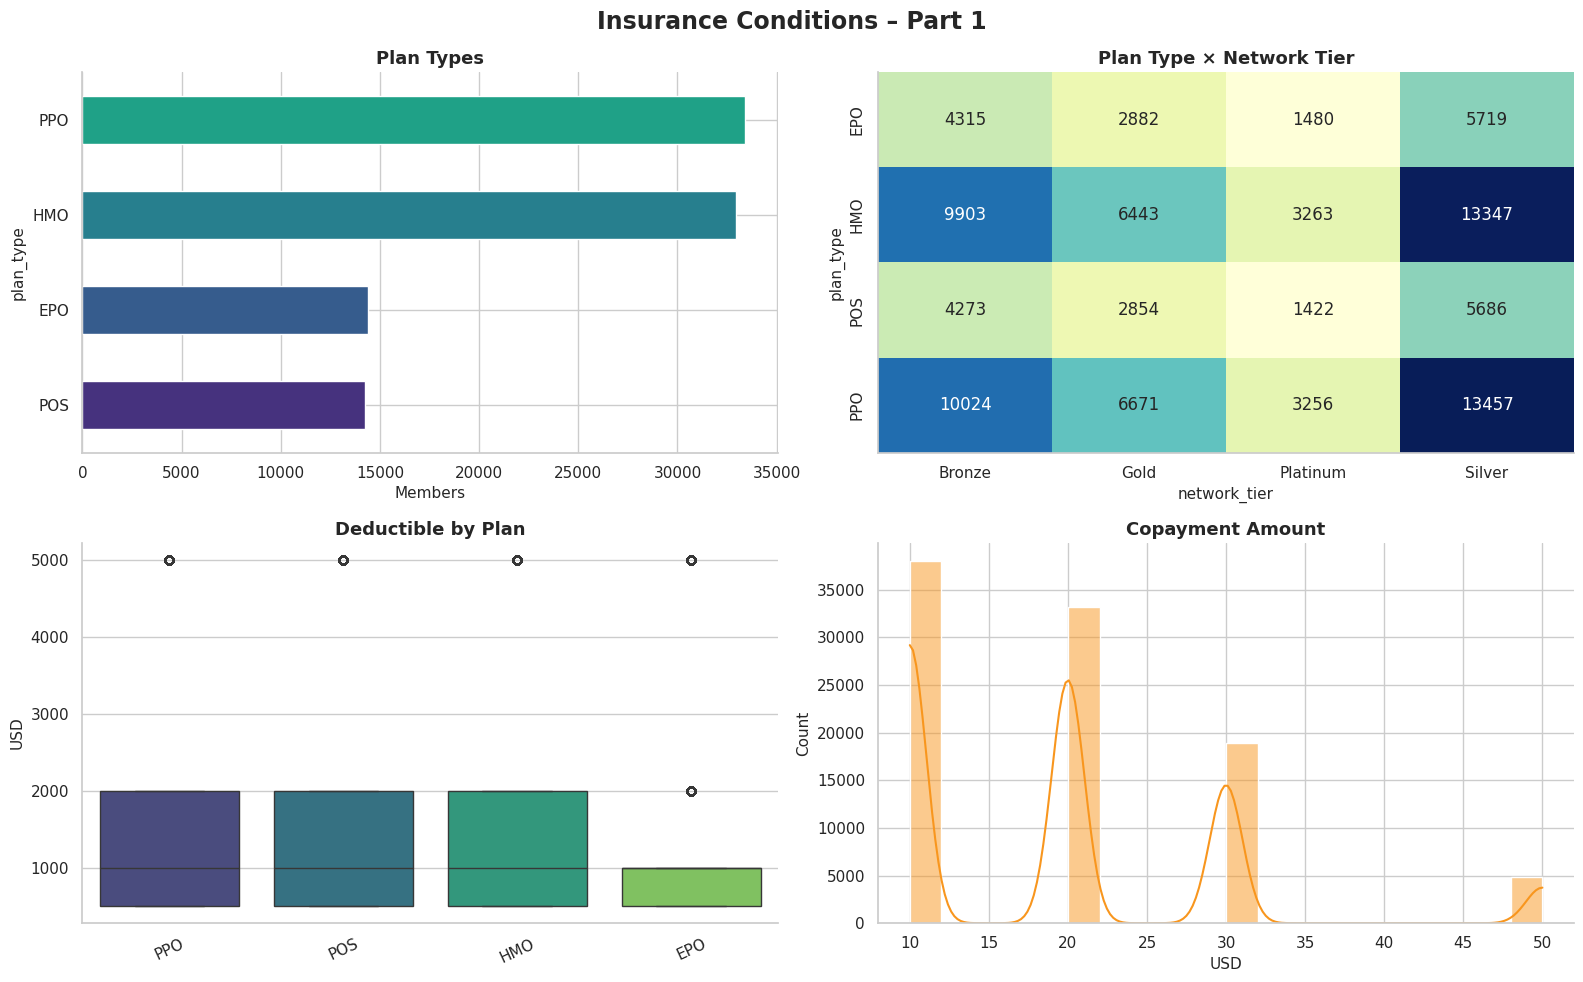

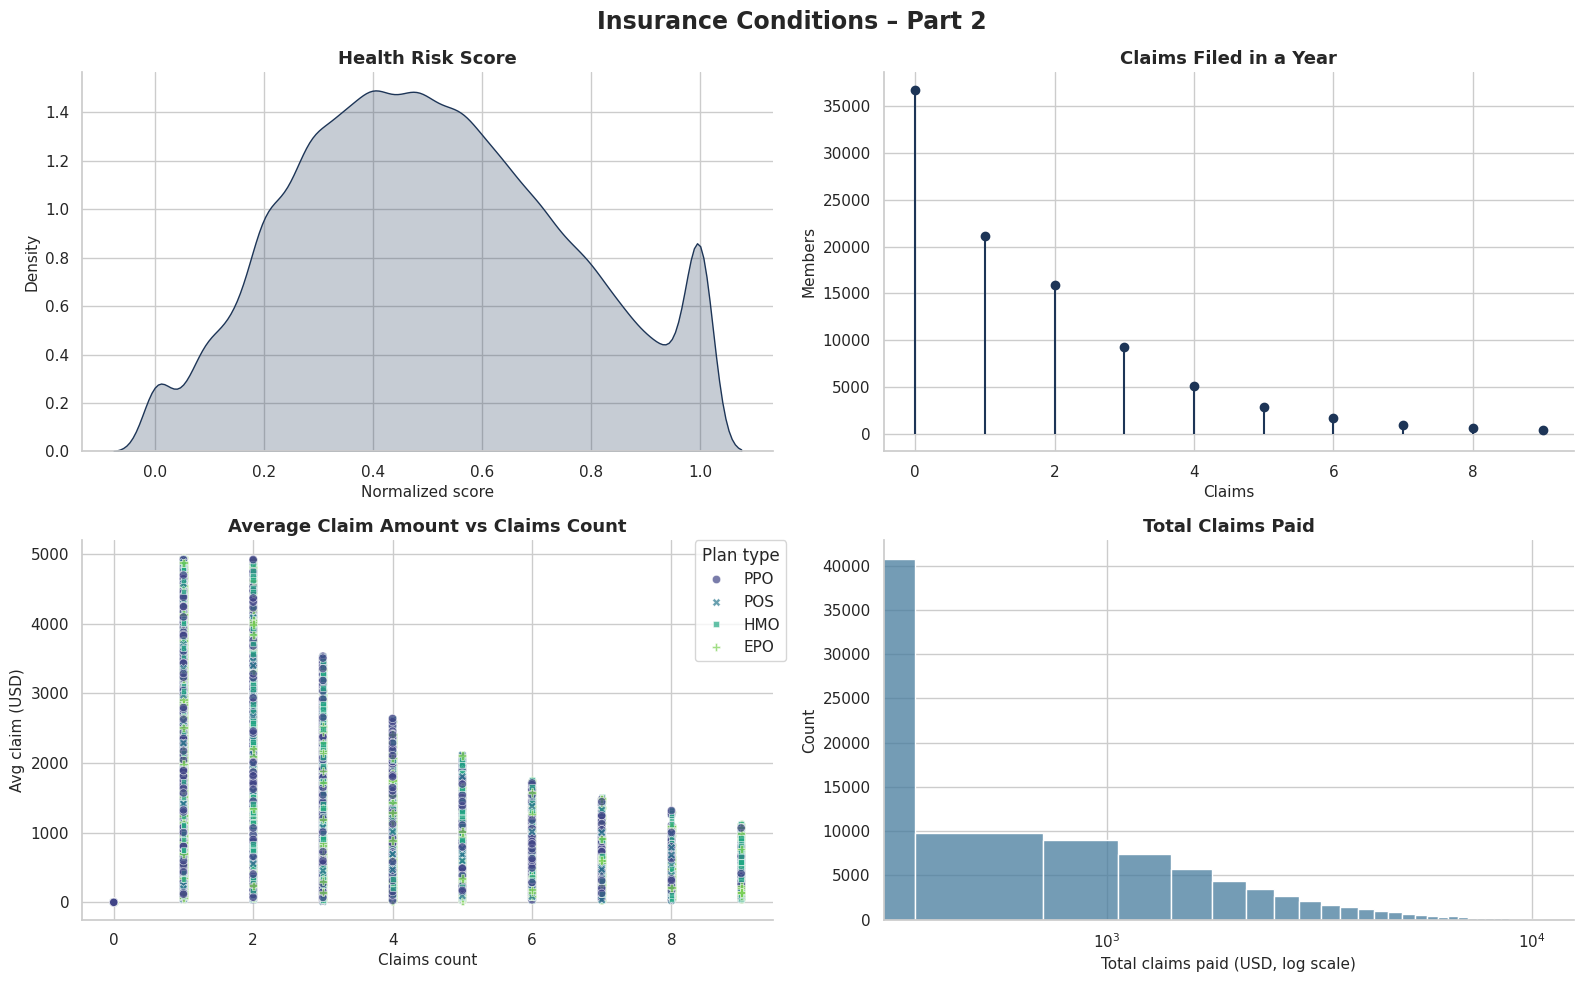

In [ ]:
print("\n3. Exploratory data analysis")
print("-" * 272)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.titlesize": 17,
    "axes.titleweight": "bold"
})

# ---------- Demographics ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Demographics Distribution", fontweight="bold")
axes = axes.flatten()

sns.histplot(df["age"], bins=range(0, 100, 5), kde=True, ax=axes[0])
axes[0].set_title("Age (yrs)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

(df["sex"]
 .value_counts(normalize=True)
 .mul(100)
 .plot(kind="bar", ax=axes[1], color=sns.color_palette("viridis", 2)))
axes[1].set_title("Sex Share")
axes[1].set_ylabel("Share (%)")

sns.histplot(df["income"], bins=30, ax=axes[2], color="#5f9ea0")
axes[2].set_title("Income Distribution")
axes[2].set_xlabel("Annual income (USD)")
axes[2].set_ylabel("Count")

(df["education"]
 .value_counts()
 .sort_values()
 .plot(kind="barh", ax=axes[3], color="#8fbc8f"))
axes[3].set_title("Education Levels")
axes[3].set_xlabel("Respondents")

sns.despine()
fig.tight_layout()
plt.show()

# ---------- Health Conditions Part 1 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Health Conditions Prevalence – Part 1", fontweight="bold")
axes = axes.flatten()

sns.histplot(df["bmi"], bins=25, kde=True, ax=axes[0], color="#7a5195")
axes[0].set_title("BMI Distribution")
axes[0].set_xlabel("BMI")

sns.countplot(x="smoker", hue="sex", data=df, ax=axes[1], palette="viridis")
axes[1].set_title("Smoker Status by Sex")
axes[1].set_xlabel("")
axes[1].legend(title="Sex")

counts = df["visits_last_year"].value_counts().sort_index()
axes[2].stem(counts.index, counts.values, basefmt=" ", linefmt="#4361ee", markerfmt="o")
axes[2].set_title("Healthcare Visits (last year)")
axes[2].set_xlabel("Number of visits")
axes[2].set_ylabel("Patients")

sns.histplot(df["medication_count"], bins=30, ax=axes[3], color="#ef476f")
axes[3].set_title("Medication Count")
axes[3].set_xlabel("Medications")

sns.despine()
fig.tight_layout()
plt.show()

# ---------- Health Conditions Part 2 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Health Conditions Prevalence – Part 2", fontweight="bold")
axes = axes.flatten()

sns.boxplot(x="sex", y="systolic_bp", data=df, ax=axes[0], palette="viridis",hue="sex")
axes[0].set_title("Systolic BP by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("mmHg")

sns.kdeplot(df["ldl"], fill=True, ax=axes[1], color="#ffb703")
axes[1].axvspan(0, 100, color="green", alpha=0.15, label="Goal < 100 mg/dL")
axes[1].set_title("LDL Cholesterol")
axes[1].set_xlabel("mg/dL")
axes[1].legend()

order = sorted(df["chronic_count"].unique())
sns.countplot(x="chronic_count", data=df, order=order, ax=axes[2], color="#118ab2")
axes[2].set_title("Chronic Conditions Count")
axes[2].set_xlabel("# of chronic diagnoses")

(df["is_high_risk"]
 .value_counts()
 .reindex([0, 1])
 .plot.bar(ax=axes[3], color=["#06d6a0", "#ef476f"]))
axes[3].set_xticks([0, 1])
axes[3].set_xticklabels(["No", "Yes"])
axes[3].set_title("High Health Risk")
axes[3].set_ylabel("Patients")

sns.despine()
fig.tight_layout()
plt.show()

# ---------- Insurance Conditions Part 1 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Insurance Conditions – Part 1", fontweight="bold")
axes = axes.flatten()

df["plan_type"].value_counts().sort_values().plot.barh(ax=axes[0], color=sns.color_palette("viridis"))
axes[0].set_title("Plan Types")
axes[0].set_xlabel("Members")

pivot = df.pivot_table(index="plan_type", columns="network_tier", aggfunc="size", fill_value=0)
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1], cbar=False)
axes[1].set_title("Plan Type × Network Tier")

sns.boxplot(x="plan_type", y="deductible", data=df, ax=axes[2], palette="viridis",hue="plan_type")
axes[2].set_title("Deductible by Plan")
axes[2].set_xlabel("")
axes[2].set_ylabel("USD")
axes[2].tick_params(axis="x", labelrotation=25)

sns.histplot(df["copay"], bins=20, kde=True, ax=axes[3], color="#f8961e")
axes[3].set_title("Copayment Amount")
axes[3].set_xlabel("USD")

sns.despine()
fig.tight_layout()
plt.show()

# ---------- Insurance Conditions Part 2 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Insurance Conditions – Part 2", fontweight="bold")
axes = axes.flatten()

sns.kdeplot(df["risk_score"], fill=True, ax=axes[0], color="#1d3557")
axes[0].set_title("Health Risk Score")
axes[0].set_xlabel("Normalized score")

claims = df["claims_count"].value_counts().sort_index()
axes[1].stem(claims.index, claims.values, basefmt=" ", linefmt="#1d3557", markerfmt="o")
axes[1].set_title("Claims Filed in a Year")
axes[1].set_xlabel("Claims")
axes[1].set_ylabel("Members")

sns.scatterplot( x="claims_count", y="avg_claim_amount", hue="plan_type", style="plan_type", data=df, ax=axes[2], palette="viridis", alpha=0.7)
axes[2].set_title("Average Claim Amount vs Claims Count")
axes[2].set_xlabel("Claims count")
axes[2].set_ylabel("Avg claim (USD)")
axes[2].legend(title="Plan type", bbox_to_anchor=(1.02, 1), borderaxespad=0)

sns.histplot(df["total_claims_paid"], bins=30, ax=axes[3], color="#457b9d")
axes[3].set_xscale("log")
axes[3].set_xlabel("Total claims paid (USD, log scale)")
axes[3].set_title("Total Claims Paid")

sns.despine()
fig.tight_layout()
plt.show()

# Selection of features & Linear Regression
In this section we will:
- Determine the 10 numerical features that we will use for the first Linear Regression.
- Do a simple Linear Regression with those 10 numerical features.

In [ ]:
print("\n4. Determining the 10 best features")
print("-" * 272)


4. Determining the 10 best features
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


We will now determine the 10 features that will be picked to do the Linear regression.  
The target variable remains **annual_medical_cost** and we rely on correlation strength to pick the most informative numeric columns.  
However we need to remove the **monthly_prenium** and **annual_prenium** column because those columns give directly an answer to what we are trying to predict.

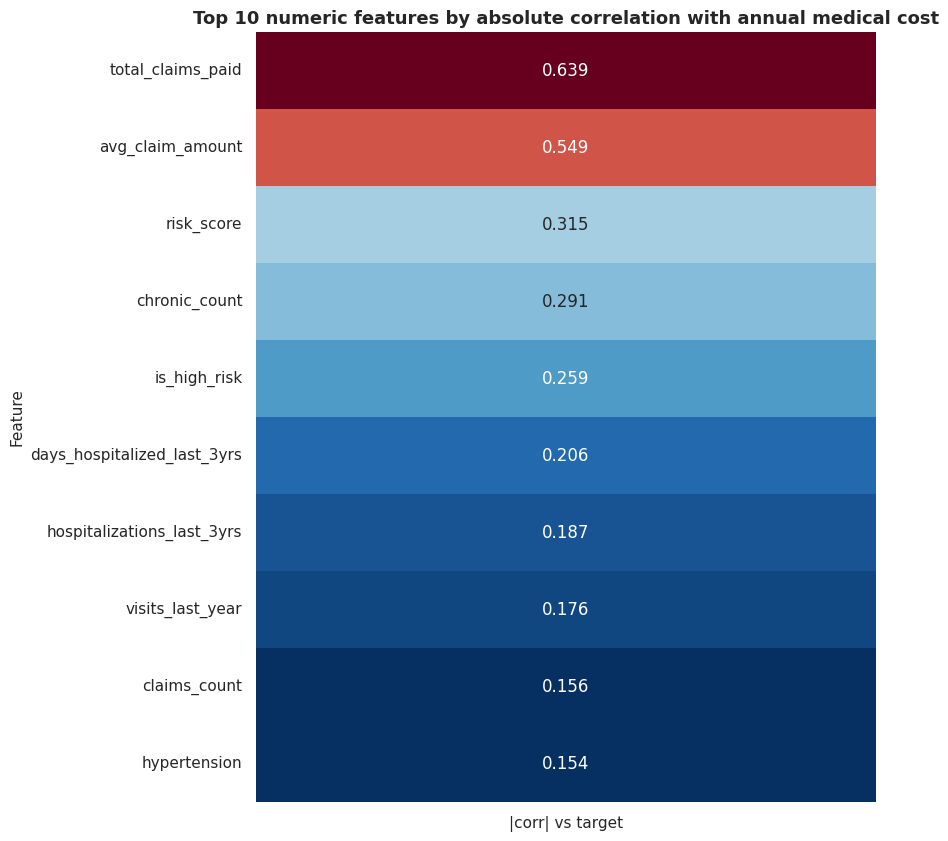

In [ ]:
target_col = 'annual_medical_cost'
numeric_features = df.select_dtypes(include=[np.number]).columns.drop([target_col,'monthly_premium','annual_premium'])
numeric_features = numeric_features.drop(labels=['person_id'], errors='ignore')

corr = (df[numeric_features].corrwith(df[target_col]).sort_values(ascending=False))
top_features = corr.head(10)
plt.figure(figsize=(8,10))
sns.heatmap(top_features.to_frame(name='|corr| vs target'), cmap='RdBu_r', annot=True, fmt='.3f', cbar=False)
plt.title('Top 10 numeric features by absolute correlation with annual medical cost')
plt.ylabel('Feature')
plt.show()

In [ ]:
print("\n5. Linear Regression")
print("-" * 272)


5. Linear Regression
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


We do a simple Linear Reggression with the top 10 features that have the highest correlation with the **annual_medical_cost** column.

In [ ]:
selected_features = top_features.index.tolist()
X = df[selected_features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

baseline = make_pipeline(StandardScaler(), LinearRegression())
baseline.fit(X_train, y_train)
linear_pred = baseline.predict(X_test)
print(linear_pred)

print(f"Linear regression, MAE : {mean_absolute_error(y_test,linear_pred)}, RMSE : {np.sqrt(mean_squared_error(y_test,linear_pred))}, R2 : {r2_score(y_test,linear_pred)}")

print('Linear coefficient :')
display(pd.Series(baseline.named_steps['linearregression'].coef_, index=selected_features).to_frame('Coefficients'))

[2097.10595663 2137.39291748 6230.77997769 ... 3886.9625298  2056.21191935
 2471.56180381]
Linear regression, MAE : 1031.3607732637095, RMSE : 1536.1785363518036, R2 : 0.5244357782454716
Linear coefficient :


,Coefficients
total_claims_paid,1910.743350
avg_claim_amount,-132.827984
risk_score,299.867034
chronic_count,167.426843
is_high_risk,-22.733513
days_hospitalized_last_3yrs,243.897746
hospitalizations_last_3yrs,23.252108
visits_last_year,-20.836200
claims_count,-901.085504
hypertension,0.756771


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_baseline = df[selected_features]
y = df[target_col]

baseline_cv = make_pipeline(StandardScaler(), LinearRegression())

scores = cross_val_score(
    baseline_cv,
    X_baseline,
    y,
    cv=kf,
    scoring="r2"
)

print("Baseline CV scores:", scores)
print("Baseline CV mean:", scores.mean())

Baseline CV scores: [0.52704364 0.52140413 0.53264456 0.52523461 0.55259205]
Baseline CV mean: 0.5317837987565651


## Comparison with randomly chosen variables and manually chosen ones

Now, we'll randmoly select 10 of the numerical columns to compare the model's performance to our baseline (with columns chosen based on correlation with target)

In [ ]:
candidate_features = [col for col in numeric_features if col != target_col]

random.seed(33)
random_features = random.sample(candidate_features, 10)
print("Randomly selected features:", random_features)

Randomly selected features: ['proc_consult_count', 'diastolic_bp', 'copay', 'provider_quality', 'liver_disease', 'proc_surgery_count', 'proc_imaging_count', 'ldl', 'avg_claim_amount', 'proc_physio_count']


In [ ]:
X = df[random_features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lr_random = make_pipeline(StandardScaler(), LinearRegression())
lr_random.fit(X_train, y_train)
linear_pred = lr_random.predict(X_test)
print(linear_pred)

print(f"Linear regression, MAE : {mean_absolute_error(y_test,linear_pred)}, RMSE : {np.sqrt(mean_squared_error(y_test,linear_pred))}, R2 : {r2_score(y_test,linear_pred)}")

print('Linear coefficient :')
display(pd.Series(lr_random.named_steps['linearregression'].coef_, index=random_features).to_frame('Coefficients'))

[2063.53356831 1902.75615651 3616.56117706 ... 3696.47519215 1917.00172267
 2761.96694332]
Linear regression, MAE : 1313.8549334724294, RMSE : 1858.7121576277175, R2 : 0.30377427288434355
Linear coefficient :


,Coefficients
proc_consult_count,56.214268
diastolic_bp,159.929980
copay,4.348209
provider_quality,-2.073440
liver_disease,55.920512
proc_surgery_count,72.488214
proc_imaging_count,68.071632
ldl,25.203763
avg_claim_amount,1213.851858
proc_physio_count,45.662968


In [ ]:
X_random = df[random_features]
lr_random_cv = make_pipeline(StandardScaler(), LinearRegression())

scores = cross_val_score(
    lr_random_cv,
    X_random,
    y,
    cv=kf,
    scoring="r2"
)

print("Random LR CV scores:", scores)
print("Random LR CV mean:", scores.mean())

Random LR CV scores: [0.30561182 0.30628589 0.30849347 0.30414885 0.33157115]
Random LR CV mean: 0.31122223587815373


We can see that it has worse performance. Higher MAE, RMSE, and lower R2

In [ ]:
print(numeric_features)

Index(['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible',
       'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'claims_count',
       'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',
       'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count',
       'is_high_risk', 'had_major_procedure'],
      dtype='object')


We'll manually choose 10 of the numeric features that we think could be important and redo the previous comparison

In [ ]:
chosen_features = ['age', 'bmi', 'hospitalizations_last_3yrs', 'medication_count', 'risk_score', 'avg_claim_amount', 'diabetes', 'cancer_history', 'proc_consult_count', 'is_high_risk']

X = df[chosen_features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lr_chosen = make_pipeline(StandardScaler(), LinearRegression())
lr_chosen.fit(X_train, y_train)
linear_pred = lr_chosen.predict(X_test)
print(linear_pred)

print(f"Linear regression, MAE : {mean_absolute_error(y_test,linear_pred)}, RMSE : {np.sqrt(mean_squared_error(y_test,linear_pred))}, R2 : {r2_score(y_test,linear_pred)}")

print('Linear coefficient :')
display(pd.Series(lr_chosen.named_steps['linearregression'].coef_, index=chosen_features).to_frame('Coefficients'))

[1653.28775927 1703.63885152 4292.11897596 ... 3589.12926404 1691.59464114
 2699.87959508]
Linear regression, MAE : 1244.9749097977303, RMSE : 1781.8803357938675, R2 : 0.36014309874414896
Linear coefficient :


,Coefficients
age,-260.660093
bmi,5.989388
hospitalizations_last_3yrs,299.836027
medication_count,3.217875
risk_score,675.542046
avg_claim_amount,1091.926532
diabetes,7.437172
cancer_history,14.989876
proc_consult_count,7.586510
is_high_risk,-24.800803


Naturally, its performance is a bit better than the fully random model, but still worse than our baseline. Which makes sense because we are not experts in this topic, but applying a bit of common sense we could imagine which features would fit best.

In [ ]:
X_chosen = df[chosen_features]
lr_chosen_cv = make_pipeline(StandardScaler(), LinearRegression())

scores = cross_val_score(
    lr_chosen_cv,
    X_chosen,
    y,
    cv=kf,
    scoring="r2"
)

print("Manual LR CV scores:", scores)
print("Manual LR CV mean:", scores.mean())

Manual LR CV scores: [0.3617488  0.36493626 0.3683814  0.36051731 0.3845303 ]
Manual LR CV mean: 0.36802281465454156


## Normalisation

Our models have already been implemented with the columns normalised. This is achieved through the `StandardScaler()' attribute. By placing the scaler, the model automatically standardises all numerical input features during training and testing without modifying the original dataset. This ensures that each feature contributes proportionally to the regression model, prevents scale-related bias, and maintains a correct train/test split by fitting the scaler only on the training data.

# Data conversion and Logistic Regression

In this section we will:


*   Convert the object columns into categorical data or binary data.
*   Select best 10 features other than previously used features.
*   Do a simple logistic regression on those features.



In [ ]:
print("\n6. Data Conversion")
print("-" * 272)


6. Data Conversion
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
df['cost_category'] = pd.qcut(df['annual_medical_cost'],q = 4, labels = ['Very Cheap','Cheap','Modarate','Expensive'])
print(df['cost_category'].value_counts())

cost_category
Cheap         23750
Very Cheap    23749
Expensive     23749
Modarate      23747
Name: count, dtype: int64


In the above block we have divided the target variable which is "annual_medical_cost" a continuous variable into four categories using quantiles.

*  Each gourp is labeled as Very Cheap, Cheap, Moderate or Expensive based on the quantiles available.

*  This method helps to convert the target variable to categorical variable which is suitable for Logistic Regression classification.

In [ ]:
print("\n7. Selecting Features")
print("-" * 272)


7. Selecting Features
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
categorical_features = ['sex','region','urban_rural','education','marital_status','employment_status','smoker']

We selected categorial features that describe demographic and lifestyle information. The reson for choosing only 7 categorical data among 10 is because we have already droped 'alcohol_freq' to handle missing values and other 2 columns such as 'plan_type' , 'network_tier' might be directly related to cost gives us answer what we are trying to predict.  

In [ ]:
numeric_feature = ['age','bmi','chronic_count']

Also we have choosed some numerical columns which help to predict the annual insurance like 'age' - older people often have higher medical costs,'bmi' - indicates health risks ,'chronic_count' - more chronic diseases is likely to more expenses.

In [ ]:
all_features = categorical_features + numeric_feature

These columns are used as predictors to determine which category a person's annual medical cost belongs to.

# Encoding

In [ ]:
df_encode = pd.get_dummies(df[all_features + ['cost_category']], drop_first = True)

This step is encoding where each category becomes a separate coulmn with either 0 or 1.

In [ ]:
print("\n8. Logistic Regression")
print("-" * 272)


8. Logistic Regression
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
X = pd.get_dummies(df[all_features], drop_first = True)
y = df['cost_category']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

# Normalization

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
logistic_reg = LogisticRegression(max_iter = 500, multi_class='multinomial')
logistic_reg.fit(X_train,y_train)


y_pred = logistic_reg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Here we did a simple multiclass Logistic Regression by spliting the data and training them.

In [ ]:
print("\nClassification Report of the model: \n")
print(classification_report(y_test,y_pred))
print("\nConfusion Matrix of the model: \n")
print(confusion_matrix(y_test,y_pred))


Classification Report of the model: 

              precision    recall  f1-score   support

       Cheap       0.26      0.10      0.14      4825
   Expensive       0.39      0.52      0.44      4727
    Modarate       0.25      0.15      0.19      4644
  Very Cheap       0.38      0.64      0.47      4803

    accuracy                           0.35     18999
   macro avg       0.32      0.35      0.31     18999
weighted avg       0.32      0.35      0.31     18999


Confusion Matrix of the model: 

[[ 481 1338  748 2258]
 [ 445 2441  725 1116]
 [ 476 1770  698 1700]
 [ 423  743  579 3058]]


*  To check the model performance we used classification report.

*  To check how many samples from each class were predicted we used Confusion matrix.

In [ ]:
X_log_reg = pd.get_dummies(df[all_features], drop_first=True)
y_log_reg = df['cost_category']

log_reg_cv = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500, multi_class='multinomial', solver='lbfgs')
)

scores = cross_val_score(
    log_reg_cv,
    X_log_reg,
    y_log_reg,
    cv=kf,
    scoring="f1_macro"   # multiclass F1 metric
)

print("Logistic Regression CV scores:", scores)
print("Logistic Regression CV mean:", scores.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression CV scores: [0.31218428 0.32013347 0.31830575 0.31793493 0.32155217]
Logistic Regression CV mean: 0.3180221198551615


## Random Forest Regression

Now, we'll implement a random forest regressor. Same as the linear regression, it works with numerical columns, and since we've obtained better results in our baseline model, we'll work with the originally chosen numerical features. Some improvements it has is that it doesn't need column normalisation and it can handle non-linear relationships better than linear regression.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_name = "RandomForest"

X = df[selected_features] # we could also use random_features / chosen_features
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

random_forest = RandomForestRegressor(n_estimators=300, random_state=42)
random_forest.fit(X_train, y_train)
rf_pred = random_forest.predict(X_test)

print("Model:", model_name)
print(f"MAE: {mean_absolute_error(y_test, rf_pred)}, RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred))}, R2: {r2_score(y_test, rf_pred)}")


Model: RandomForest
MAE: 916.6551840091603, RMSE: 1472.146457709285, R2: 0.5632551176349314


In [ ]:
X_rf = df[selected_features]
y_rf = df[target_col]

random_forest_cv = RandomForestRegressor(n_estimators=300, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(random_forest_cv, X_rf, y_rf, cv=kf, scoring="r2")

print("Random Forest CV R2 scores:", cv_scores)
print("Random Forest CV mean R2:", cv_scores.mean())

Random Forest CV R2 scores: [0.57251029 0.56062768 0.57142149 0.57037482 0.59252932]
Random Forest CV mean R2: 0.5734927223361832


Comparing with our baseline, this model performs better, since it has lower MAE ans RMSE, and higher R2. WE have some pregression


## Gradient Boosting Classification

For this classification task, we'll use previously categorized columns and we'll redirect our prediction task to: "Is the patient high cost?", whith high cost being above 75th percentile. This classifier also doesn't require any scalling as it can directly work with our data.

Again, we'll work with the originally chosen features, as the model requires numerical columns to be used.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_name = "GradientBoosting_Classifier"

df["high_cost"] = (df[target_col] > df[target_col].quantile(0.75)).astype(int)

X = df[selected_features]
y = df["high_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

grad_boost = GradientBoostingClassifier(random_state=42)
grad_boost.fit(X_train, y_train)
pred = grad_boost.predict(X_test)

print("Model:", model_name)
print(classification_report(y_test, pred))


Model: GradientBoosting_Classifier
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     21433
           1       0.86      0.59      0.70      7066

    accuracy                           0.87     28499
   macro avg       0.87      0.78      0.81     28499
weighted avg       0.87      0.87      0.86     28499



In [ ]:
X_gb = df[selected_features]
y_gb = df["high_cost"]

grad_boost_cv = GradientBoostingClassifier(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(grad_boost_cv, X_gb, y_gb, cv=kf, scoring="f1_macro")

print("Random Forest CV R2 scores:", cv_scores)
print("Random Forest CV mean R2:", cv_scores.mean())

Random Forest CV R2 scores: [0.80914655 0.81016727 0.81275212 0.80664933 0.80926843]
Random Forest CV mean R2: 0.8095967378598449


## Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_name = "DecisionTree"

X = pd.get_dummies(df[all_features], drop_first = True)
y = df['cost_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)

print("Model:", model_name)
print("\nClassification Report of the model: \n")
print(classification_report(y_test, dt_pred))
print("\nConfusion Matrix of the model: \n")
print(confusion_matrix(y_test, dt_pred))

Model: DecisionTree

Classification Report of the model: 

              precision    recall  f1-score   support

       Cheap       0.27      0.26      0.26      7282
   Expensive       0.30      0.30      0.30      7066
    Modarate       0.25      0.25      0.25      7000
  Very Cheap       0.32      0.31      0.32      7151

    accuracy                           0.28     28499
   macro avg       0.28      0.28      0.28     28499
weighted avg       0.28      0.28      0.28     28499


Confusion Matrix of the model: 

[[1914 1703 1829 1836]
 [1647 2136 1961 1322]
 [1703 1946 1776 1575]
 [1904 1358 1638 2251]]


In [ ]:
X_dt = pd.get_dummies(df[all_features], drop_first = True)
y_dt = df['cost_category']

decision_tree_cv = DecisionTreeClassifier(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(decision_tree_cv, X_dt, y_dt, cv=kf, scoring="f1_macro")

print("Random Forest CV R2 scores:", cv_scores)
print("Random Forest CV mean R2:", cv_scores.mean())

Random Forest CV R2 scores: [0.28525654 0.2817651  0.28425872 0.28490101 0.28294619]
Random Forest CV mean R2: 0.2838255141223474


## Naive Bayes

Now, we'll implement a Naive Bayes classifier. NB handles mixed data types effectively and works seamlessly with our one-hot encoded categorical features. It delivers probabilistic outputs, providing confidence scores and probability estimates for each cost category classification, which adds valuable interpretability to our predictions.

In [ ]:
from sklearn.naive_bayes import GaussianNB

model_name = "NaiveBayes"

X = pd.get_dummies(df[all_features], drop_first=True)
y = df['cost_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

naive_bayes = make_pipeline(StandardScaler(), GaussianNB())
naive_bayes.fit(X_train, y_train)
nb_pred = naive_bayes.predict(X_test)

print("Model:", model_name)
print("\nClassification Report: \n")
print(classification_report(y_test, nb_pred))
print("\nConfusion Matrix: \n")
print(confusion_matrix(y_test, nb_pred))

Model: NaiveBayes

Classification Report: 

              precision    recall  f1-score   support

       Cheap       0.26      0.12      0.16      7282
   Expensive       0.36      0.52      0.43      7066
    Modarate       0.27      0.08      0.12      7000
  Very Cheap       0.35      0.63      0.45      7151

    accuracy                           0.34     28499
   macro avg       0.31      0.34      0.29     28499
weighted avg       0.31      0.34      0.29     28499


Confusion Matrix: 

[[ 842 2260  508 3672]
 [ 783 3672  561 2050]
 [ 826 2791  543 2840]
 [ 810 1398  411 4532]]


In [ ]:
X_nb = pd.get_dummies(df[all_features], drop_first = True)
y_nb = df['cost_category']

naive_bayes_cv = make_pipeline(StandardScaler(), GaussianNB())

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(naive_bayes_cv, X_nb, y_nb, cv=kf, scoring="f1_macro")

print("Random Forest CV R2 scores:", cv_scores)
print("Random Forest CV mean R2:", cv_scores.mean())

Random Forest CV R2 scores: [0.29474928 0.28953494 0.29619812 0.28826048 0.30322705]
Random Forest CV mean R2: 0.29439397310058835


In summary, we have the following available models:


*   Baseline: Linear Regression with most correlated features
*   Linear Regression with random features
*   Linear Regression with manually chosen features
*   Logistic Regression
*   Random Forest Regression
*   Gradient Boosting Classification
*   Decision Trees
*   Naive Bayes



## Validation

To ensure robust and unbiased model performance, we've applied a three step validation procedure after each model implementation:

*   Train/validation/test split:\
The dataset is split into 80% training and 20% testing, using stratified sampling to preserve class proportions.

*   k-fold cross-validation:\
All candidate models (Linear/Logistic Regression, Random Forest, Gradient Boosting, Decision Trees, Naive Bayes) are evaluated using 5-fold cross-validation on the training set to reduce variance and avoid overfitting.

*   Hyperparameter tuning:\
For non-baseline models (Random Forest, Gradient Boosting, Logistic Regression), we perform grid search over relevant hyperparameters using GridSearchCV.
The best hyperparameter combination is selected based on mean cross-validation performance (accuracy / RMSE depending on the task).

1. imports

In [ ]:
import numpy as np
import pandas as pd
import random
from scipy.special import expit

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

2. define feature groups

In [ ]:
# target for regression
target_col = "annual_medical_cost"

# baseline features
numeric_features = df.select_dtypes(include=[np.number]).columns.drop(
    [target_col, "monthly_premium", "annual_premium"]
)
numeric_features = numeric_features.drop(labels=["person_id"], errors="ignore")

corr = df[numeric_features].corrwith(df[target_col]).sort_values(ascending=False)
selected_features = corr.head(10).index.tolist()

# random features
candidate_features = [col for col in numeric_features if col != target_col]
random.seed(33)
random_features = random.sample(candidate_features, 10)

# chosen features
chosen_features = ['age', 'bmi', 'hospitalizations_last_3yrs', 'medication_count', 'risk_score', 'avg_claim_amount', 'diabetes', 'cancer_history', 'proc_consult_count', 'is_high_risk']


# logistic regression
categorical_features = ['sex','region','urban_rural','education','marital_status','employment_status','smoker']
numeric_lr_features = ['age','bmi','chronic_count']
all_lr_features = categorical_features + numeric_lr_features

# classification ft set
all_features = all_lr_features
y_category = df["cost_category"] # target


In [ ]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status',
       'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp',
       'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium',
       'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension',
       'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease',
       'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
       'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'cost_category', 'high_cost'],
      dtype='object')

3. regression preprocessing pipelines

In [ ]:
preprocess_baseline = ColumnTransformer([
    ("num", StandardScaler(), selected_features)
])

preprocess_random = ColumnTransformer([
    ("num", StandardScaler(), random_features)
])

preprocess_chosen = ColumnTransformer([
    ("num", StandardScaler(), chosen_features)
])

# For regressors using all selected features
preprocess_all_reg = ColumnTransformer([
    ("num", StandardScaler(), selected_features)
])


4. classification preprocessing pipelines



In [ ]:
# logistic reg
preprocess_logistic = ColumnTransformer([
    ("num", StandardScaler(), numeric_lr_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# decision trees, nb, random forest
X_class_full = pd.get_dummies(df[all_features], drop_first=True)

5. helper functions

In [ ]:
# Convert regression scores into pseudo probabilities
def to_prob(pred):
    return expit(pred)

# Plot ROC
def plot_roc(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")

# Plot confusion matrix (classification only)
def plot_conf(y_true, y_prob, title):
    pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

6. regression evaluation

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

def make_scaler(df_subset):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), df_subset.columns.tolist())
        ],
        remainder="drop"
    )

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# ------------------------------------------------------
# DEFINE REGRESSION MODELS WITH THEIR OWN FEATURE SETS
# ------------------------------------------------------
regression_models = {
    "baseline": {
        "features": selected_features,
        "preprocessor": preprocess_baseline,
        "model": LinearRegression()
    },
    "linear_reg_random": {
        "features": random_features,
        "preprocessor": preprocess_random,
        "model": LinearRegression()
    },
    "linear_reg_chosen": {
        "features": chosen_features,
        "preprocessor": preprocess_chosen,
        "model": LinearRegression()
    },
    "decision_tree_reg": {
        "features": selected_features,   # no scaling needed but harmless
        "preprocessor": preprocess_all_reg,
        "model": DecisionTreeRegressor(random_state=42)
    },
    "random_forest_reg": {
        "features": selected_features,
        "preprocessor": preprocess_all_reg,
        "model": RandomForestRegressor(n_estimators=300, random_state=42)
    }
}

# ------------------------------------------------------
# RUN ALL REGRESSORS WITH THEIR OWN FEATURE SETS
# ------------------------------------------------------
reg_results = []

for name, cfg in regression_models.items():

    # pull each model’s dedicated feature list
    X = df[cfg["features"]]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42
    )

    # construct pipeline dynamically
    pipe = Pipeline([
        ("prep", cfg["preprocessor"]),
        ("model", cfg["model"])
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    reg_results.append([name, mae, rmse, r2])

# Display results
reg_results_df = pd.DataFrame(reg_results, columns=["Model", "MAE", "RMSE", "R²"])
display(reg_results_df.sort_values("MAE"))


,Model,MAE,RMSE,R²
4,random_forest_reg,658.310078,1028.434230,0.786853
3,decision_tree_reg,762.588391,1218.939261,0.700574
0,baseline,784.124436,1136.270640,0.739811
2,linear_reg_chosen,1244.974910,1781.880336,0.360143
1,linear_reg_random,1309.286736,1853.591928,0.307605


7. classification evaluation

In [ ]:
# log reg
X_lr = df[all_lr_features]
y_lr = df["cost_category"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.3, random_state=42, stratify=y_lr
)

logistic_model = Pipeline([
    ("prep", preprocess_logistic),
    ("model", LogisticRegression(max_iter=600))
])

logistic_model.fit(X_train_lr, y_train_lr)
prob_lr = logistic_model.predict_proba(X_test_lr)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


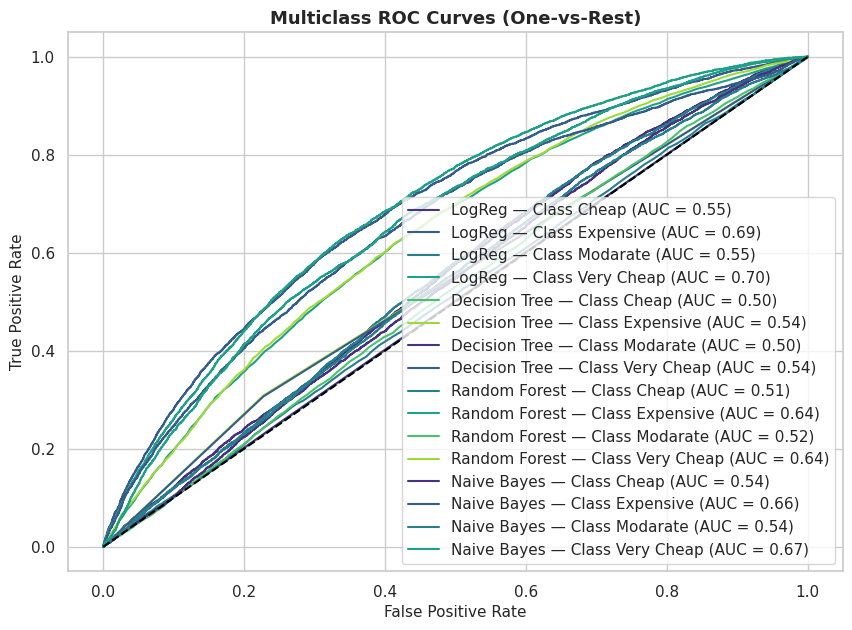

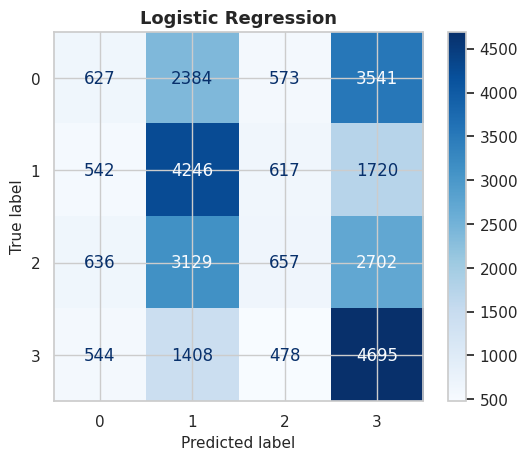

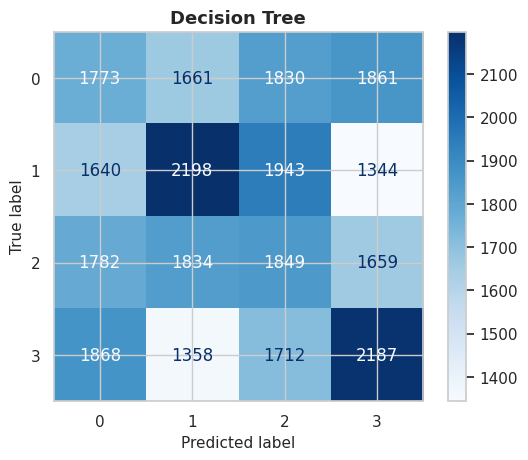

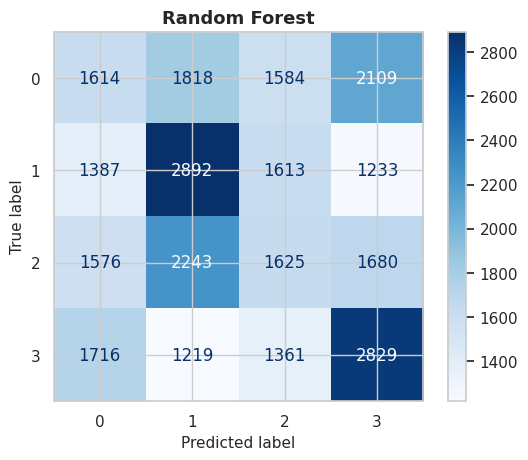

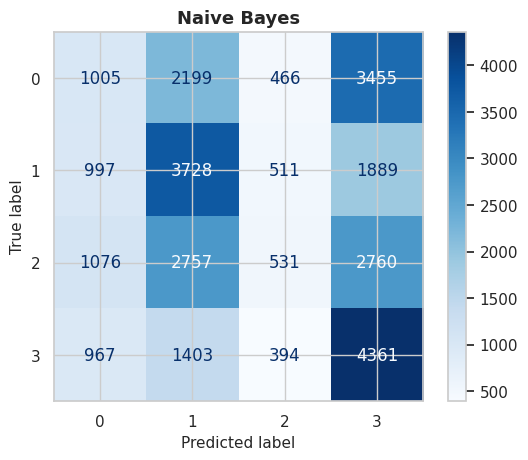

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------------------------
# LOGISTIC REGRESSION
# -------------------------
X_lr = df[all_lr_features]
y_lr = df["cost_category"]

classes = sorted(y_lr.unique())
y_lr_bin = label_binarize(y_lr, classes=classes)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.3, random_state=42, stratify=y_lr
)

logistic_model = Pipeline([
    ("prep", preprocess_logistic),
    ("model", LogisticRegression(max_iter=600, multi_class="ovr"))
])

logistic_model.fit(X_train_lr, y_train_lr)
prob_lr = logistic_model.predict_proba(X_test_lr)

# binarize test labels
y_test_lr_bin = label_binarize(y_test_lr, classes=classes)

# -------------------------
# TREE + NB MODELS
# -------------------------
X_class = X_class_full
y_class = y_category
y_class_bin = label_binarize(y_class, classes=classes)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)

y_test_clf_bin = label_binarize(y_test_clf, classes=classes)

classification_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Naive Bayes": GaussianNB()
}

# -------------------------
# MULTICLASS ROC PLOTS
# -------------------------
plt.figure(figsize=(10,7))

# Logistic Regression
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_lr_bin[:, i], prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"LogReg — Class {c} (AUC = {roc_auc:.2f})")

# Other classifiers
for name, model in classification_models.items():
    model.fit(X_train_clf, y_train_clf)
    prob = model.predict_proba(X_test_clf)

    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_clf_bin[:, i], prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} — Class {c} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("Multiclass ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------------
# CONFUSION MATRICES
# -------------------------
def plot_conf(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

plot_conf(y_test_lr, logistic_model.predict(X_test_lr), "Logistic Regression")

for name, model in classification_models.items():
    preds = model.predict(X_test_clf)
    plot_conf(y_test_clf, preds, name)


roc for individual models

In [ ]:
def plot_multiclass_roc(y_true, y_prob, classes, model_name):
    y_true_bin = label_binarize(y_true, classes=classes)

    shades = ["#08306B", "#2171B5", "#6BAED6", "#C6DBEF"]

    plt.figure(figsize=(8,6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color=shades[i],
                 label=f"{cls} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve — {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


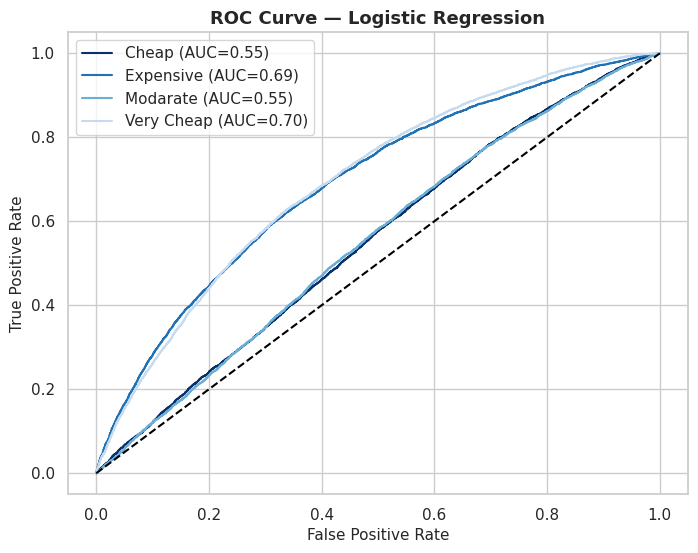

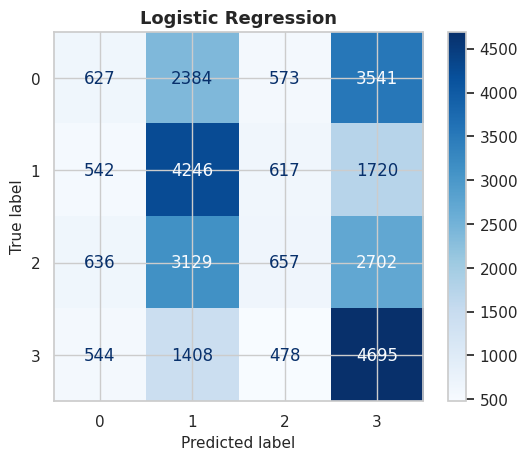

In [ ]:
prob_lr = logistic_model.predict_proba(X_test_lr)
plot_multiclass_roc(y_test_lr, prob_lr, classes, "Logistic Regression")
plot_conf(y_test_lr, logistic_model.predict(X_test_lr), "Logistic Regression")

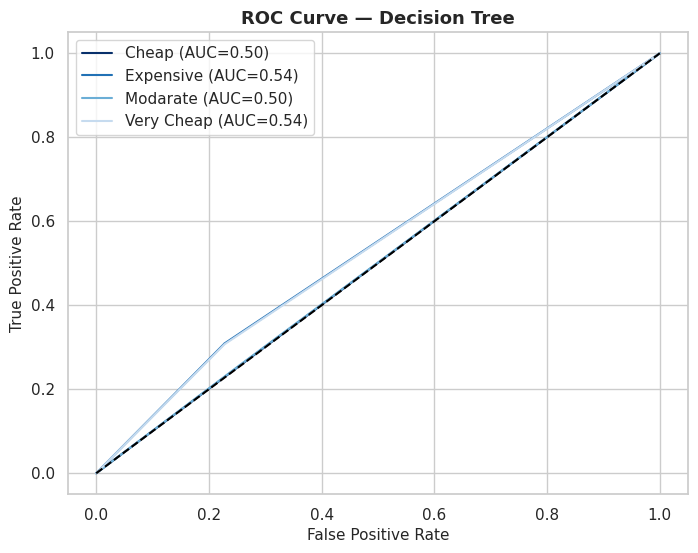

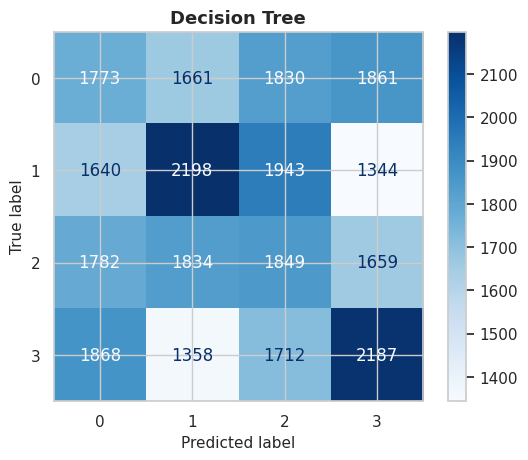

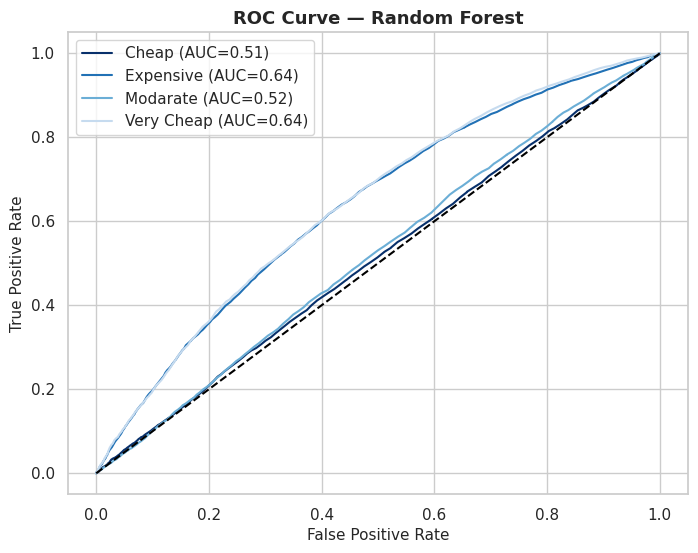

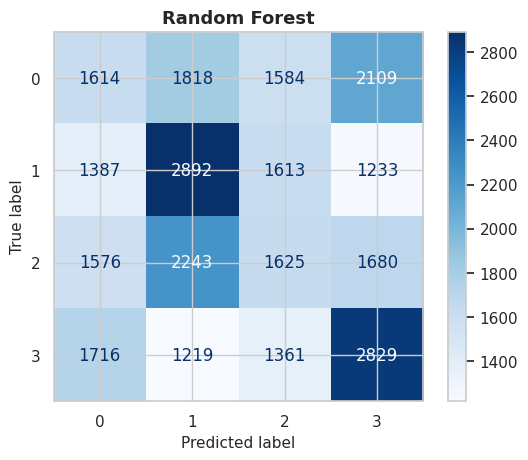

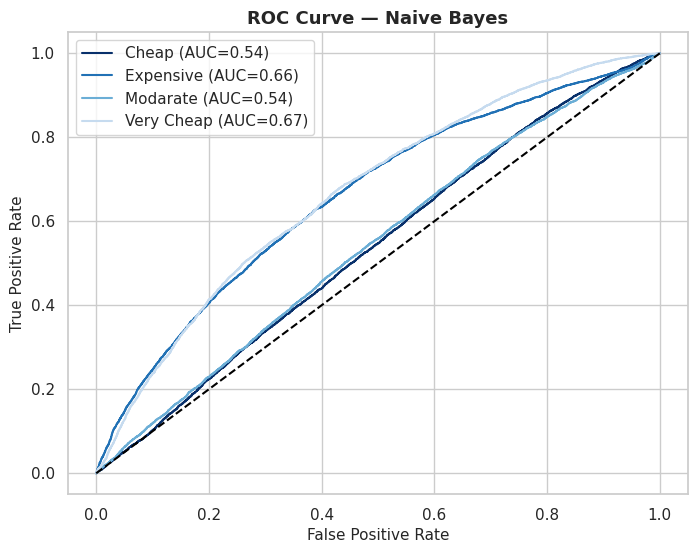

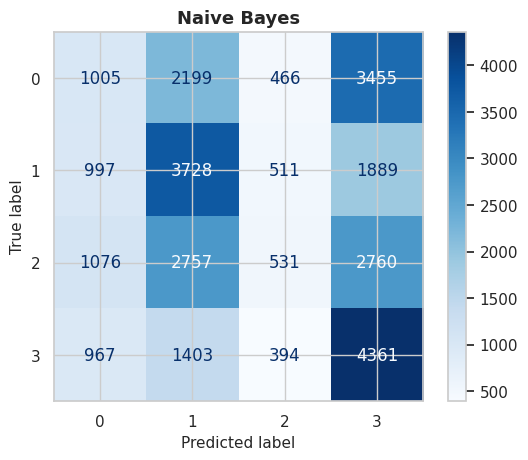

In [ ]:
for name, model in classification_models.items():
    model.fit(X_train_clf, y_train_clf)
    prob = model.predict_proba(X_test_clf)

    # ROC plot
    plot_multiclass_roc(y_test_clf_bin, prob, classes, name)

    # Confusion matrix
    plot_conf(y_test_clf, model.predict(X_test_clf), name)

## hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Regression data
X_reg = df[selected_features]
y_reg = df[target_col]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

regression_models = {
    "baseline": {
        "features": selected_features,
        "preprocessor": preprocess_baseline,
        "model": LinearRegression()
    },
    "linear_reg_random": {
        "features": random_features,
        "preprocessor": preprocess_random,
        "model": LinearRegression()
    },
    "linear_reg_chosen": {
        "features": chosen_features,
        "preprocessor": preprocess_chosen,
        "model": LinearRegression()
    },
    "decision_tree_reg": {
        "features": selected_features,   # no scaling needed but harmless
        "preprocessor": preprocess_all_reg,
        "model": DecisionTreeRegressor(random_state=42)
    },
    #"random_forest_reg": {
      #  "features": selected_features,
      #  "preprocessor": preprocess_all_reg,
      #  "model": RandomForestRegressor(n_estimators=300, random_state=42)
    #}
}

# Hyperparameter grids
reg_grids = {
    "baseline": {},
    "linear_reg_random": {},
    "linear_reg_chosen": {},
    "decision_tree_reg": {
        "model__max_depth": [3, 5, 10, 20, None],
        "model__min_samples_leaf": [1, 3, 5, 10]
    },
    #"random_forest_reg": {
     #   "model__n_estimators": [100, 200, 300],
     #   "model__max_depth": [None, 10, 20],
     #   "model__min_samples_leaf": [1, 3, 5]
    #}
}

regression_results = []
best_reg_models = {}

for name, cfg in regression_models.items():
    print(f"\n🔍 Tuning {name}...")

    # Extract model-specific settings
    features = cfg["features"]
    preprocessor = cfg["preprocessor"]
    base_model = cfg["model"]

    # Prepare X/y for THIS model
    X = df[features]
    y = df[target_col]

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Build pipeline
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", base_model)
    ])

    # Select correct hyperparameter grid
    reg_grid = {}

    if name == "decision_tree_reg":
        reg_grid = {
            "model__max_depth": [3, 5, 10, 20, None],
            "model__min_samples_leaf": [1, 3, 5]
        }
    elif name == "random_forest_reg":
        reg_grid = {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3, 5]
        }

    # Perform tuning
    grid = GridSearchCV(
        pipe,
        reg_grid,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(X_train_reg, y_train_reg)

    # Save best model
    best_reg_models[name] = grid.best_estimator_

    # Evaluate
    preds = best_reg_models[name].predict(X_test_reg)
    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)

    regression_results.append([name, mae, rmse, r2])

regression_results_df = pd.DataFrame(
    regression_results, columns=["Model", "MAE", "RMSE", "R²"]
).sort_values("MAE")

print("\n📊 Regression Model Performance (Tuned)")
display(regression_results_df)


🔍 Tuning baseline...

🔍 Tuning linear_reg_random...

🔍 Tuning linear_reg_chosen...

🔍 Tuning decision_tree_reg...

📊 Regression Model Performance (Tuned)


,Model,MAE,RMSE,R²
3,decision_tree_reg,640.848187,991.075132,0.802058
0,baseline,784.124436,1136.270640,0.739811
2,linear_reg_chosen,1244.974910,1781.880336,0.360143
1,linear_reg_random,1309.286736,1853.591928,0.307605


In [ ]:
# Classification data
X_clf = pd.get_dummies(df[categorical_features + numeric_feature], drop_first=True)
y_clf = df["cost_category"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

classification_models = {
    "logistic_reg": LogisticRegression(),
    "naive_bayes": GaussianNB(),
    "decision_tree_clf": DecisionTreeClassifier(),
}

clf_grids = {
    "logistic_reg": {
        "C": [0.1, 1, 5],
        "penalty": ["l2"]
    },
    "naive_bayes": {},   # no tuning
    "decision_tree_clf": {
        "max_depth": [3, 5, 10, 20, None],
        "min_samples_leaf": [1, 3, 5]
    }
}

classification_results = []
best_clf_models = {}

for name, model in classification_models.items():
    print(f"\n🔍 Tuning {name}...")

    grid = GridSearchCV(
        model, clf_grids[name],
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X_train_clf, y_train_clf)

    best_clf_models[name] = grid.best_estimator_

    preds = best_clf_models[name].predict(X_test_clf)

    # Only compute AUC if model supports predict_proba
    if hasattr(best_clf_models[name], "predict_proba"):
        probs = best_clf_models[name].predict_proba(X_test_clf)
        # Convert y_test to integer labels if needed
        auc = roc_auc_score(y_test_clf, probs, multi_class="ovr")
    else:
        probs = None
        auc = np.nan

    acc = accuracy_score(y_test_clf, preds)
    f1 = f1_score(y_test_clf, preds, average="macro")

    classification_results.append([name, acc, f1, auc])

classification_results_df = pd.DataFrame(
    classification_results, columns=["Model", "Accuracy", "F1", "AUC"]
).sort_values("F1", ascending=False)

print("\n📊 Classification Model Performance (Tuned)")
display(classification_results_df)


🔍 Tuning logistic_reg...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



🔍 Tuning naive_bayes...

🔍 Tuning decision_tree_clf...

📊 Classification Model Performance (Tuned)


,Model,Accuracy,F1,AUC
2,decision_tree_clf,0.348188,0.325658,0.605876
0,logistic_reg,0.360644,0.322968,0.622546
1,naive_bayes,0.337731,0.294005,0.601356


In [ ]:
from sklearn.metrics import roc_curve, auc  # ensure auc is the function

def plot_multiclass_roc(y_true, y_prob, classes, model_name):

    # Binarize integer labels
    y_true_bin = label_binarize(y_true, classes=classes)

    # Proper modern colormap handler
    cmap = plt.colormaps["tab10"]

    plt.figure(figsize=(8,6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)  # guaranteed to work now

        plt.plot(
            fpr, tpr,
            color=cmap(i),
            linewidth=2,
            label=f"{cls} (AUC={roc_auc:.2f})"
        )

    plt.plot([0,1],[0,1],"k--", linewidth=1)
    plt.title(f"ROC Curve — {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
def plot_conf(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


 Evaluating ROC and Confusion Matrix for: logistic_reg


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


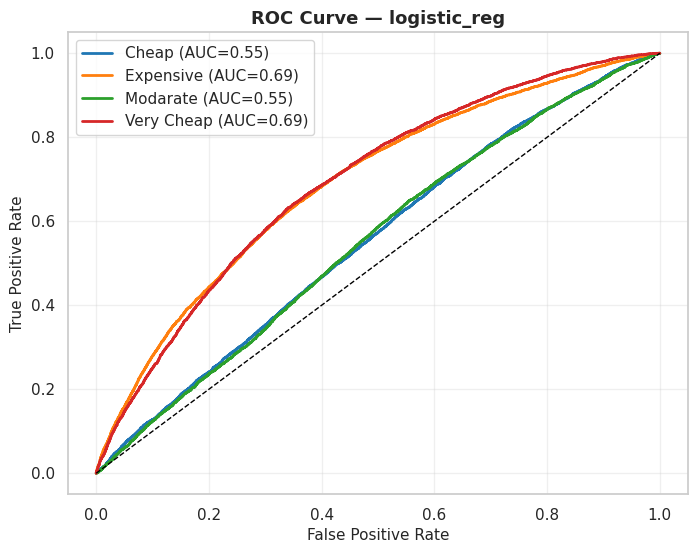

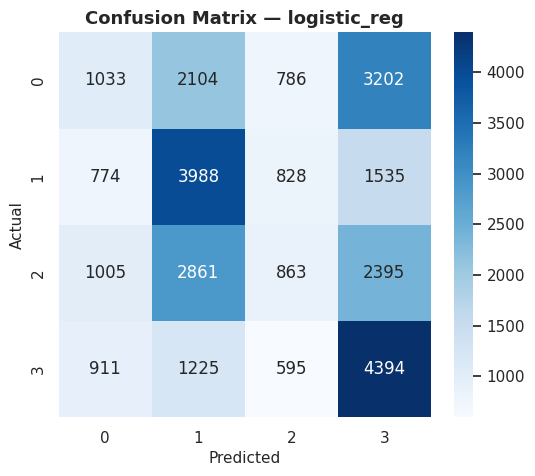


 Evaluating ROC and Confusion Matrix for: naive_bayes


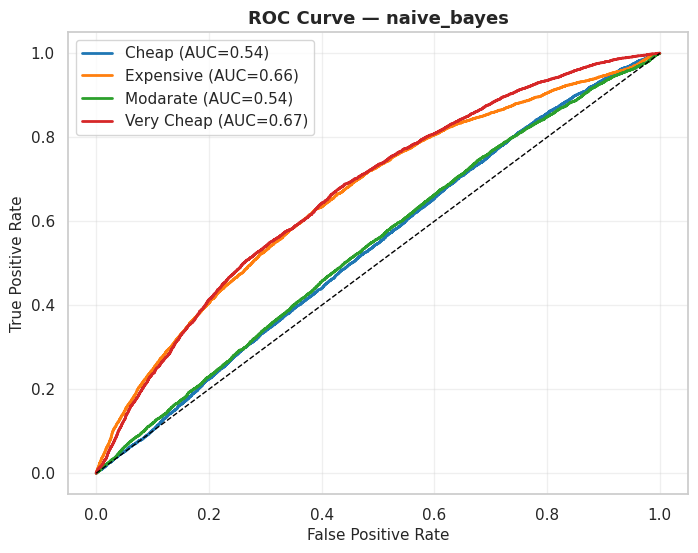

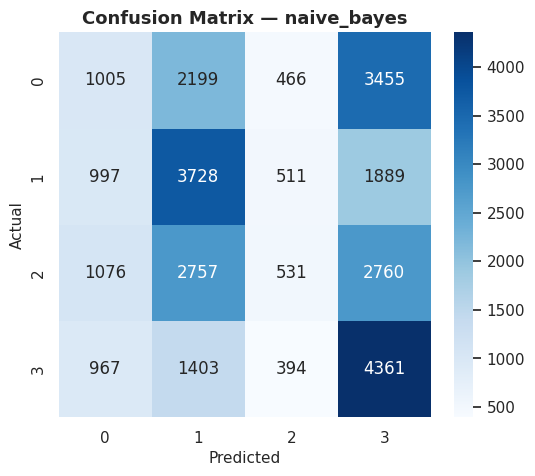


 Evaluating ROC and Confusion Matrix for: decision_tree_clf


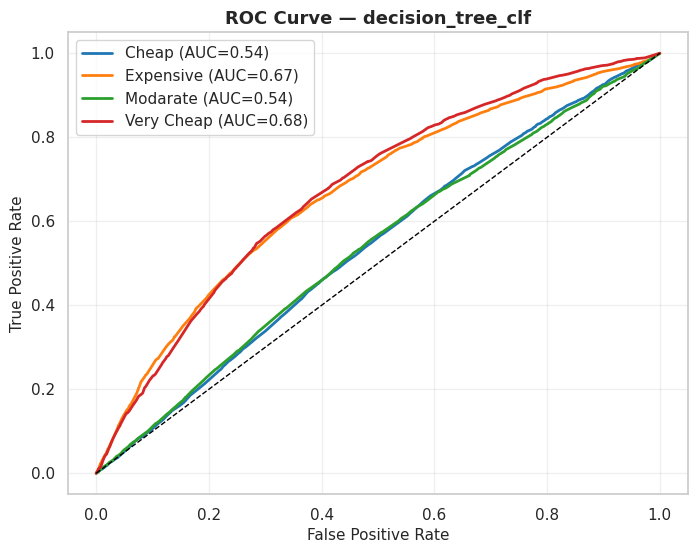

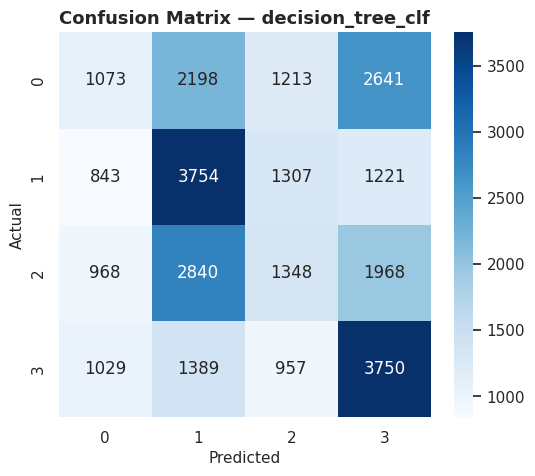

In [ ]:
classes = sorted(y_train_clf.unique())

for name, model in best_clf_models.items():
    print(f"\n Evaluating ROC and Confusion Matrix for: {name}")

    # Must fit the tuner-selected best estimator
    model.fit(X_train_clf, y_train_clf)

    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_clf)
        plot_multiclass_roc(y_test_clf, probs, classes, name)
    else:
        print(f" {name} does not support predict_proba — skipping ROC curve.")

    # Confusion matrix
    preds = model.predict(X_test_clf)
    plot_conf(y_test_clf, preds, name)
